# BUSINESS UNDERSTANDING

## Business Understanding

Financial institutions face significant risk when approving loans, as some applicants may default on repayment.
The objective of this project is to build a Loan Default Prediction System that helps lenders assess the risk level of applicants before loan approval.

## Problem Statement

To predict whether a borrower is likely to default on a loan using historical financial and demographic data.

## Business Objective

- Reduce financial losses due to loan defaults.

- Assist banks/NBFCs in making data-driven lending decisions.

- Identify high-risk applicants early.

- Improve portfolio risk management.

### Machine Learning Objective

Build a classification model that predicts:

- 0 → No Default

- 1 → Default

# DATA UNDERSTANDING

## Data Understanding

The dataset contains borrower-level information including income, employment type, loan details, and repayment behavior.

## Target Variable

- default → Indicates whether the borrower defaulted.
  - 0 = No Default
  - 1 = Default

## Dataset Characteristics

- Contains both numerical and categorical features.

- Realistic class imbalance exists (defaults are fewer than non-defaults).

- Suitable for classification modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

## Settings for notebook

In [2]:
sns.set_style("whitegrid")
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1200)

## Load Dataset

In [3]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="risksaarthi"
)

df = pd.read_sql("SELECT * FROM loan_data", conn)
conn.close()

df.head()

C:\Users\Gunjan\AppData\Local\Temp\ipykernel_376\574478482.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM loan_data", conn)


,id,age,annual_income,cibil_score,employment_type,loan_amount,loan_tenure,emi,existing_loans,default
0,1,59,1466672,642,Salaried,1387444,233,17349,0,0
1,2,49,1211256,710,Self-Employed,4182239,98,64859,5,0
2,3,35,1010803,692,Self-Employed,4409432,211,47320,4,0
3,4,28,272158,728,Salaried,3125000,218,33185,0,0
4,5,41,1295661,675,Salaried,1515034,202,16499,2,0


## Dataset Overview

**Initial Data Exploration**

Understanding structure, data types, and size of the dataset.

In [4]:
df.shape

(10000000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000000 entries, 0 to 9999999
Data columns (total 10 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   id               int64 
 1   age              int64 
 2   annual_income    int64 
 3   cibil_score      int64 
 4   employment_type  object
 5   loan_amount      int64 
 6   loan_tenure      int64 
 7   emi              int64 
 8   existing_loans   int64 
 9   default          int64 
dtypes: int64(9), object(1)
memory usage: 762.9+ MB


In [6]:
df.describe()

,id,age,annual_income,cibil_score,loan_amount,loan_tenure,emi,existing_loans,default
count,"10,000,000.00","10,000,000.00","10,000,000.00","10,000,000.00","10,000,000.00","10,000,000.00","10,000,000.00","10,000,000.00","10,000,000.00"
mean,"5,000,000.50",40.50,"1,350,008.18",698.67,"2,550,306.61",126.01,"49,368.86",2.50,0.10
std,"2,886,751.49",11.54,"663,875.87",97.98,"1,414,750.46",66.10,"47,746.12",1.71,0.31
min,1.00,21.00,"200,000.00",300.00,"100,000.00",12.00,902.00,0.00,0.00
25%,"2,500,000.75",31.00,"775,214.00",632.00,"1,325,044.75",69.00,"20,076.00",1.00,0.00
50%,"5,000,000.50",41.00,"1,350,074.00",699.00,"2,550,737.00",126.00,"38,628.00",3.00,0.00
75%,"7,500,000.25",51.00,"1,924,944.00",767.00,"3,775,694.25",183.00,"60,439.00",4.00,0.00
max,"10,000,000.00",60.00,"2,500,000.00",900.00,"5,000,000.00",240.00,"458,375.00",5.00,1.00


#### Key Observations

- Features show wide variation in scale, indicating need for normalization.

- Presence of skewness suggests some borrowers have extremely high values.

- Data appears realistic for financial modelling.

## Target Variable Distribution

In [7]:
df['default'].value_counts()
df['default'].value_counts(normalize=True)

default
0   0.90
1   0.10
Name: proportion, dtype: float64

#### Key Insights
Dataset is highly imbalanced, which reflects real banking scenarios where most customers repay. This makes the problem a Risk Detection Problem, not a simple classification.

Because only ~10% default:

- Accuracy alone is misleading 

- ROC-AUC and Recall are more important 

This is why we select model using ROC-AUC, not Accuracy.

## Default vs Non-Default

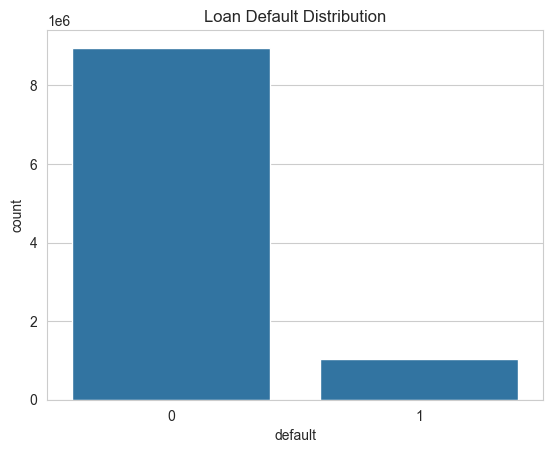

In [8]:
sns.countplot(x='default', data=df)
plt.title("Loan Default Distribution")
plt.show()

## Income vs Default Risk

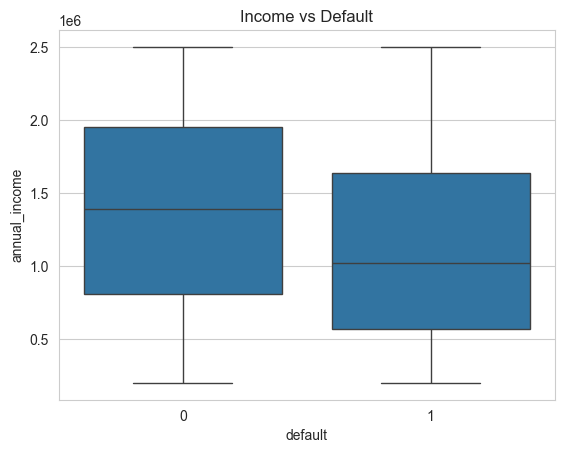

In [9]:
sns.boxplot(x='default', y='annual_income', data=df)
plt.title("Income vs Default")
plt.show()

## CIBIL Score Behaviour

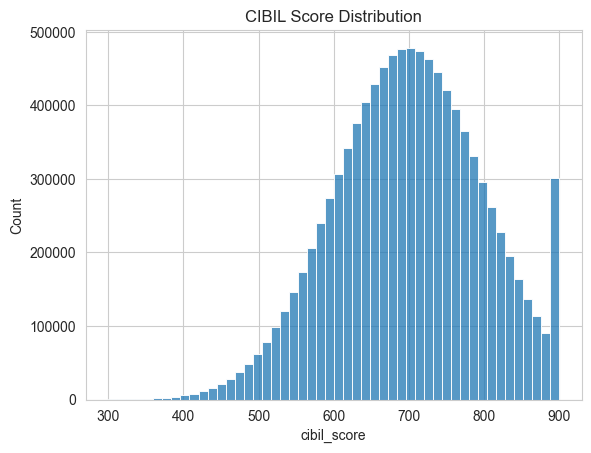

In [10]:
sns.histplot(df['cibil_score'], bins=50)
plt.title("CIBIL Score Distribution")
plt.show()

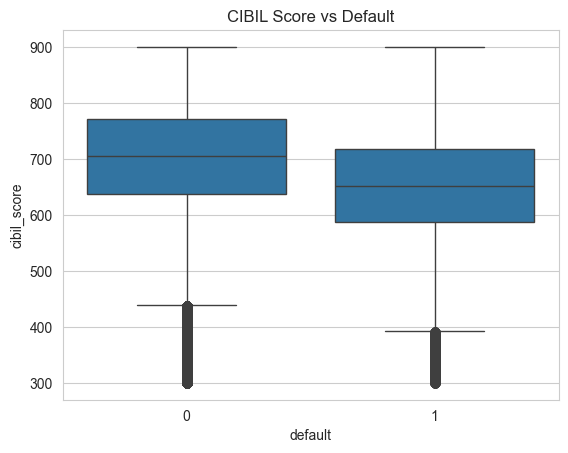

In [11]:
sns.boxplot(x='default', y='cibil_score', data=df)
plt.title("CIBIL Score vs Default")
plt.show()

#### Insight: Numerical Distributions

- Many variables are right-skewed.

- Outliers exist, representing high-value loans/incomes.

- These patterns justify using robust ML models.

## Loan Amount Risk Analysis

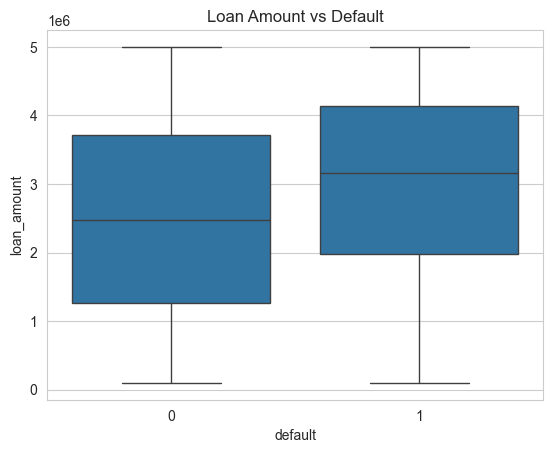

In [12]:
sns.boxplot(x='default', y='loan_amount', data=df)
plt.title("Loan Amount vs Default")
plt.show()

#### Insight: Loan Size vs Risk

- Higher loan amounts show increased variability among defaulters.

- Suggests larger loans carry higher uncertainty and repayment risk.

## Employment Type Risk

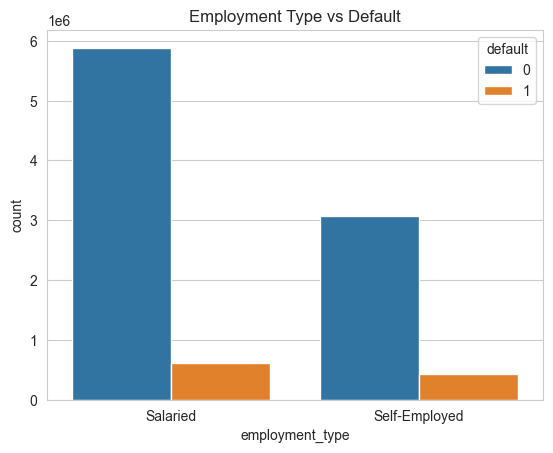

In [13]:
sns.countplot(x='employment_type', hue='default', data=df)
plt.title("Employment Type vs Default")
plt.show()

#### Insight: Employment Type Impact

- Certain employment categories show higher default rates.

- Indicates employment stability is an important risk indicator.

## Correlation Heatmap

In [14]:
eda_df = df.copy()

In [15]:
eda_df['employment_type'] = eda_df['employment_type'].map({
    'Salaried': 0,
    'Self-Employed': 1
})

In [16]:
eda_df = eda_df.drop(columns=['id'])

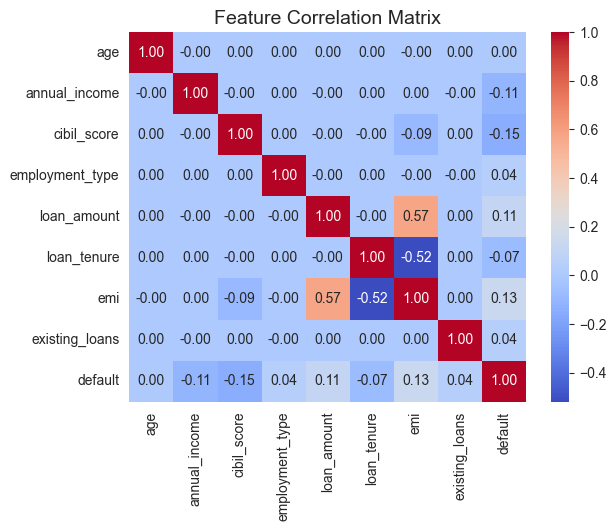

In [17]:
sns.heatmap(
    eda_df.corr(),
    annot=True,
    fmt=".2f",          
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix", fontsize=14)
plt.show()

#### Key Relationships Observed:

- Loan Amount ↑ → Risk ↑
- EMI ↑ → Risk ↑
- CIBIL Score ↑ → Risk ↓
- Income ↑ → Risk ↓
- Existing Loans ↑ → Risk ↑
- No extreme multicollinearity observed.
- Multiple features contribute independently to default prediction.

## Risk Feature Engineering Insight

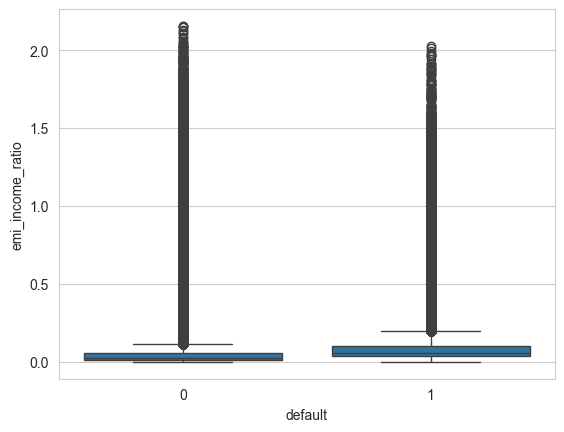

In [18]:
df['emi_income_ratio'] = df['emi'] / df['annual_income']

sns.boxplot(x='default', y='emi_income_ratio', data=df)
plt.show()

## Overall EDA Conclusion

- Dataset reflects real-world credit risk behavior.

- Clear class imbalance exists requiring careful model evaluation.

- Both demographic and financial attributes influence default.

- Data is suitable for building predictive risk models.

- EDA confirms feasibility of machine learning approach.
